# Electricity demand forecasting

In [36]:
%load_ext autoreload
%autoreload 2
import sys
if ".." not in sys.path:
    sys.path.append("..")

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error, mean_absolute_percentage_error
import pandas as pd
from itertools import product

from signature.learning.signature_transform import RollingSignatureTransform, EFMSignatureTransform
from signature.learning.hyperparameters_optimization import optimize_lam_cv, grid_search_cv, grid_search_efm
import signature.tensor_algebra as ta

my_green = "#5b6c64"
my_copper = "#B56246"
plt.rcParams["figure.figsize"]        = ((1 + np.sqrt(5)) / 2 * 5, 5)
plt.rcParams["figure.autolayout"]     = True
plt.rcParams["patch.force_edgecolor"] = False
plt.rcParams["axes.grid"]             = True
plt.rcParams['axes.prop_cycle']       = matplotlib.cycler(color=[my_green, my_copper, "#322B4D", "#28BC9C", "#71074E"])
color_cycle = [my_green, my_copper, "#322B4D", "#28BC9C", "#71074E"]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Load data

In [2]:
file_path = "data/consumption_data.csv"

df = pd.read_csv(file_path, decimal=".")
df["DateTime"] = pd.to_datetime(df["DateTime"])
temp = np.array(df["Temperature"])
consumption = np.array(df["Consumption"])
dates = df["DateTime"]
df

,DateTime,HalfHour,Consumption,Temperature
0,2012-01-01 00:00:00,0,58315.0,11.313
1,2012-01-01 00:30:00,1,58315.0,11.273
2,2012-01-01 01:00:00,2,56231.0,11.232
3,2012-01-01 01:30:00,3,56075.0,11.192
4,2012-01-01 02:00:00,4,55532.0,11.152
...,...,...,...,...
70123,2015-12-31 21:30:00,43,55762.0,7.362
70124,2015-12-31 22:00:00,44,55140.0,7.362
70125,2015-12-31 22:30:00,45,56150.0,7.362
70126,2015-12-31 23:00:00,46,59518.0,7.362


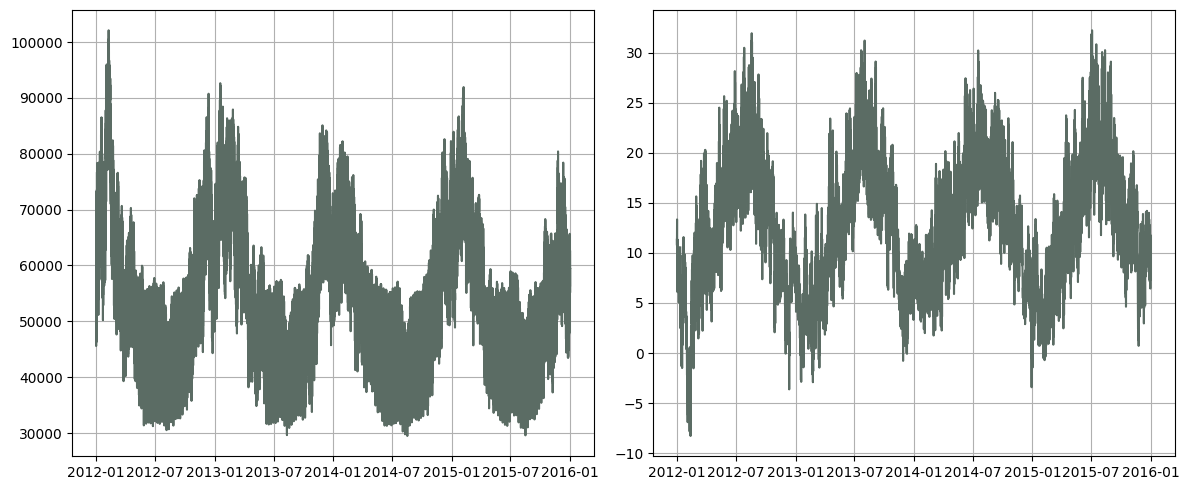

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(dates, consumption)
ax[1].plot(dates, temp)

In [15]:
### Fit RidgeSig on data and calculate error metrics

# Set parameters and define dictionaries
delay = 7 * 48
# n_windows = 31
# windows_days = np.array(range(delay_days, n_windows + delay_days))
# windows = [48 * i for i in windows_days]
# trunc_orders = [4, 5, 6]

test_start_date = "2015-01-01 00:00:00"
test_start_idx = np.where(dates >= test_start_date)[0][0]

n_train = (df["DateTime"] < "2014-01-01 00:00:00").sum()
n_valid = ((df["DateTime"] >= "2014-01-01 00:00:00") &
           (df["DateTime"] < "2015-01-01 00:00:00")).sum()
burn_in = 36 * 48

time_grid = np.arange(len(dates)) / 2  # time measured in hours
path = np.vstack([
    time_grid,
    temp,
]).T

NORM_CONST = 10_000
y_train = (consumption[burn_in:test_start_idx] - consumption[burn_in-delay:test_start_idx-delay]) / NORM_CONST
y_test = (consumption[test_start_idx:] - consumption[test_start_idx - delay:-delay]) / NORM_CONST
y = np.concatenate([y_train, y_test])

X = np.hstack([time_grid[:, None], path])
X_train = X[:test_start_idx]
X_test = X

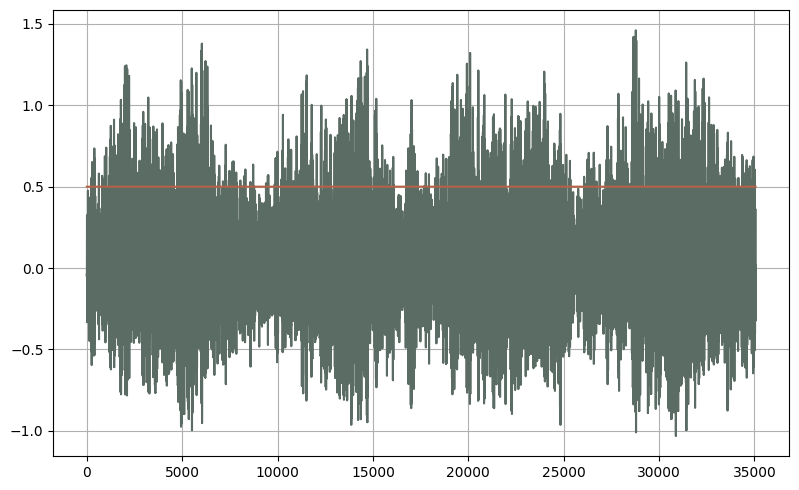

In [16]:
plt.plot(time_grid[1:], np.diff(path[:, 1], axis=0))
plt.plot(time_grid[1:], np.diff(path[:, 0], axis=0))

In [17]:
trunc = 5
# lam = [0.01531109, 0.00928143, 0.00206748]
lam = [0.00695193, 0.0001]
alpha = 0.01

pipe = Pipeline([
    ('sig', EFMSignatureTransform(trunc=trunc, lam=lam, burn_in=burn_in)),
    ('scaler', StandardScaler()),
    ('regressor', Ridge(alpha=alpha))
])

dim = path.shape[1]

In [35]:
# lam_grid = np.logspace(-2, 1, 5) / 24
lam_grid = 1 / np.logspace(0.5, 4, 20)
lam_2d = np.array(list(product(lam_grid, lam_grid)))

rng = np.random.default_rng(seed=42)
# sampled_grid = rng.choice(lam_3d, size=500, replace=False)

param_grid = {
    'sig__trunc': [5],
    'sig__lam': list(lam_2d), # list(sampled_grid),
    'regressor__alpha': [0.01]
}

# best_lam = optimize_lam_cv(
#     X=X_train,
#     y=y_train,
#     model=pipe,
#     burn_in=burn_in,
#     n_splits=3,
#     bounds=[(0.001, 0.05)]*dim,
#     init_guess=[0.00363636, 0.02      , 0.002     ],
#     optimizer="Powell"
# )
# pipe.set_params(sig__lam=best_lam)


best_p, all_results = grid_search_cv(
    X=X_train,
    y=y_train,
    model=pipe,
    param_grid=param_grid,
    burn_in=burn_in,
    n_splits=3,
)
print("Calibrated parameters:", best_p)
pipe.set_params(**best_p)

  0%|          | 0/400 [00:00<?, ?it/s]Error processing line 1 of /opt/homebrew/Caskroom/miniconda/base/envs/signature/lib/python3.9/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "/opt/homebrew/Caskroom/miniconda/base/envs/signature/lib/python3.9/site.py", line 177, in addpackage
      exec(line)
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
  0%|          | 1/400 [00:14<1:33:45, 14.10s/it]

Params: {'regressor__alpha': 0.01, 'sig__lam': array([0.31622777, 0.31622777]), 'sig__trunc': 5} | Mean CV MSE: 0.256591


  0%|          | 2/400 [00:26<1:28:34, 13.35s/it]

Params: {'regressor__alpha': 0.01, 'sig__lam': array([0.31622777, 0.20691381]), 'sig__trunc': 5} | Mean CV MSE: 0.257376


  1%|          | 3/400 [00:39<1:25:52, 12.98s/it]

...

100%|█████████▉| 399/400 [1:24:42<00:12, 12.71s/it]

Params: {'regressor__alpha': 0.01, 'sig__lam': array([0.0001    , 0.00015283]), 'sig__trunc': 5} | Mean CV MSE: 1106.859732


100%|██████████| 400/400 [1:24:55<00:00, 12.74s/it]

Params: {'regressor__alpha': 0.01, 'sig__lam': array([0.0001, 0.0001]), 'sig__trunc': 5} | Mean CV MSE: 1409.363368
Calibrated parameters: {'sig__trunc': 5, 'sig__lam': array([0.00695193, 0.0001    ]), 'regressor__alpha': 0.01}


Pipeline(steps=[('sig',
                 EFMSignatureTransform(burn_in=1728,
                                       lam=array([0.00695193, 0.0001    ]),
                                       trunc=5)),
                ('scaler', StandardScaler()),
                ('regressor', Ridge(alpha=0.01))])

Train Metrics: RMSE = 2833.8936, MAE = 1912.1082, MAPE = 0.0356, R2 = 0.6823
Test  Metrics: RMSE = 2786.1036, MAE = 1951.9573, MAPE = 0.0367, R2 = 0.6035


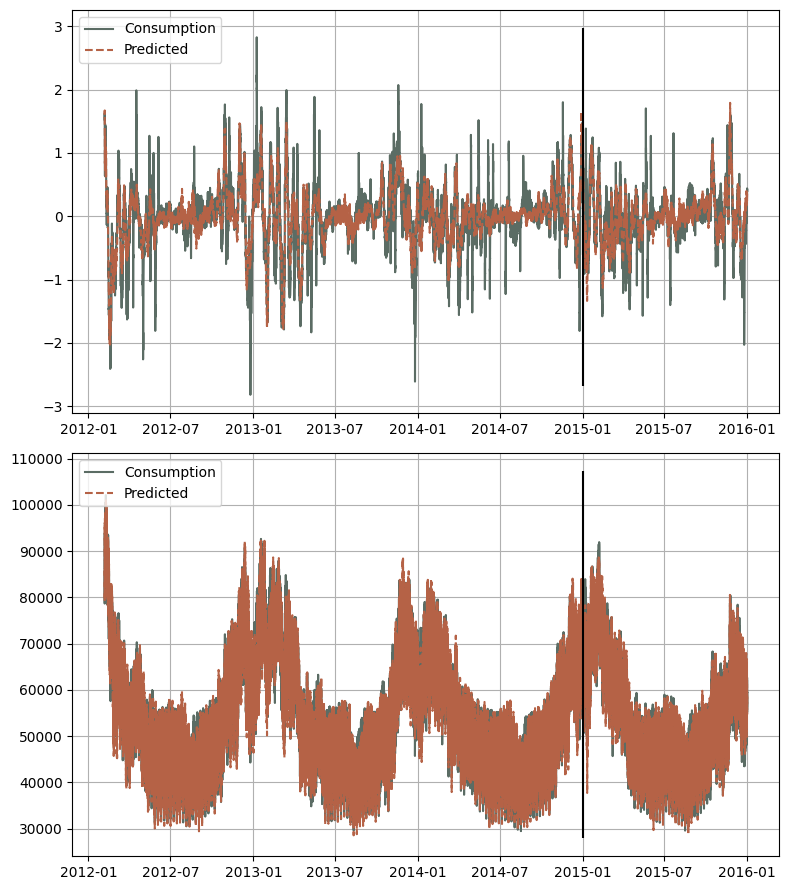

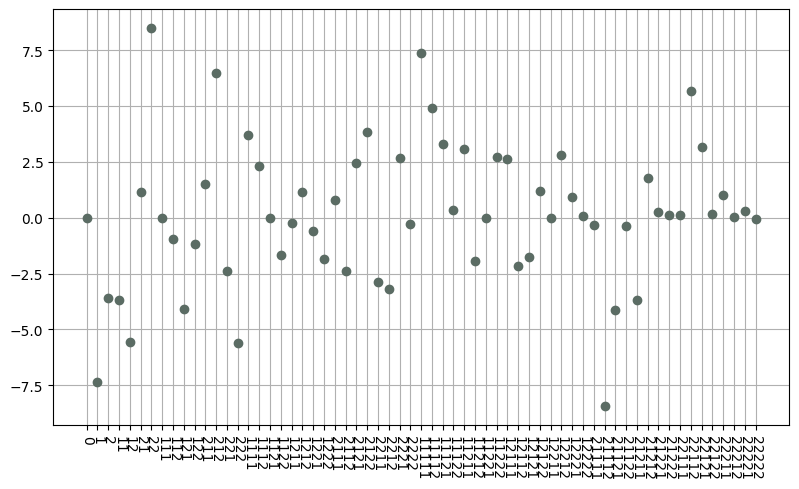

In [18]:
# 5. Fit on Train Data
# Note: y_train is already aligned with the output of sig.transform(X_train)
pipe.fit(X_train, y_train)

# 6. Predict
y_pred_efm = pipe.predict(X_test)
y_pred_train = pipe.predict(X_train)
y_pred_test = y_pred_efm[-len(y_test):] # Slice the test prediction to match y_test

# 7. Compute Metrics
metrics = {
    "Train": {
        "RMSE": root_mean_squared_error(y_train * NORM_CONST, y_pred_train * NORM_CONST),
        "MAE": mean_absolute_error(y_train * NORM_CONST, y_pred_train * NORM_CONST),
        "MAPE": mean_absolute_percentage_error(consumption[burn_in-delay:test_start_idx-delay] + y_train * NORM_CONST,
                                               consumption[burn_in-delay:test_start_idx-delay] + y_pred_train * NORM_CONST),
        "R2": r2_score(y_train, y_pred_train)
    },
    "Test ": {
        "RMSE": root_mean_squared_error(y_test * NORM_CONST, y_pred_test * NORM_CONST),
        "MAE": mean_absolute_error(y_test * NORM_CONST, y_pred_test * NORM_CONST),
        "MAPE": mean_absolute_percentage_error(consumption[test_start_idx - delay:-delay] + y_test * NORM_CONST,
                                               consumption[test_start_idx - delay:-delay] + y_pred_test * NORM_CONST),
        "R2": r2_score(y_test, y_pred_test)
    }
}

for split, results in metrics.items():
    print(f"{split} Metrics: " + ", ".join([f"{key} = {value:.4f}" for (key, value) in results.items()]))

fig, ax = plt.subplots(2, 1, figsize=(8, 4.5 * 2))
ax[0].plot(dates[burn_in:], y, label="Consumption")
ax[0].plot(dates[burn_in:], y_pred_efm, "--", label="Predicted")
ax[0].vlines(x=pd.Timestamp(test_start_date), ymin=0.95 * np.min(y), ymax=1.05 * np.max(y), color="k")
ax[0].legend(loc="upper left")

ax[1].plot(dates[burn_in:], consumption[burn_in:], label="Consumption")
ax[1].plot(dates[burn_in:], consumption[burn_in-delay:-delay] + y_pred_efm * NORM_CONST, "--", label="Predicted")
ax[1].vlines(x=pd.Timestamp(test_start_date), ymin=0.95 * np.min(consumption), ymax=1.05 * np.max(consumption), color="k")
ax[1].legend(loc="upper left")
plt.show()

vol_coef = ta.from_array(array=pipe["regressor"].coef_, dim=dim, trunc=trunc)
ta.plot_coefficients(vol_coef, trunc=trunc)

### Rolling Signature

In [19]:
path = np.vstack([
    time_grid,
    temp,
]).T

NORM_CONST = 10_000
y_train = (consumption[burn_in:test_start_idx] - consumption[burn_in-delay:test_start_idx-delay]) / NORM_CONST
y_test = (consumption[test_start_idx:] - consumption[test_start_idx - delay:-delay]) / NORM_CONST
y = np.concatenate([y_train, y_test])

X = path
X_train = X[:test_start_idx]
X_test = X

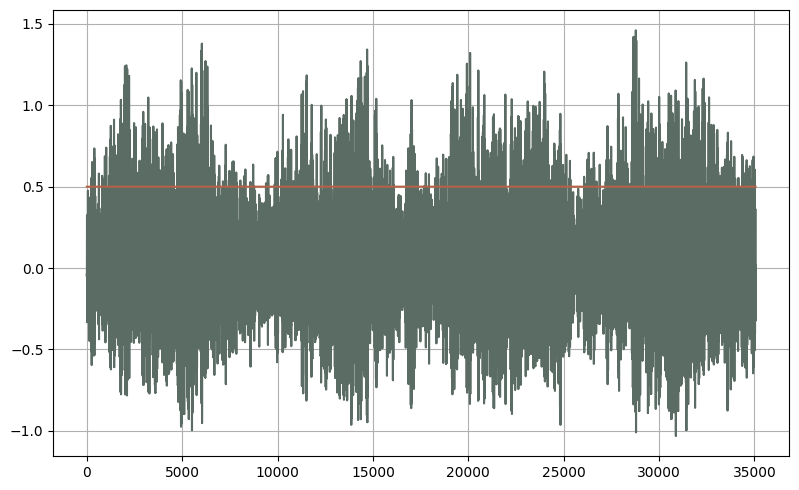

In [9]:
plt.plot(time_grid[1:], np.diff(path[:, 1], axis=0))
# plt.plot(time_grid[1:], np.diff(path[:, 2], axis=0))
plt.plot(time_grid[1:], np.diff(path[:, 0], axis=0))

In [20]:
trunc = 5
window_size = 8  * 48
alpha = 0.001

pipe_sliding = Pipeline([
    ('sig', RollingSignatureTransform(trunc=trunc, window_size=window_size, burn_in=burn_in)),
    ('scaler', StandardScaler()),
    ('regressor', Ridge(alpha=alpha))
])

dim = path.shape[1]

In [45]:
window_size_grid = np.arange(3 * 48, 20 * 48, 12)
print(window_size_grid.shape)

param_grid = {
    'sig__trunc': [5],
    'sig__window_size': window_size_grid,
    'regressor__alpha': [0.001, 0.01]
}

best_p, all_results = grid_search_cv(
    X=X_train,
    y=y_train,
    model=pipe_sliding,
    param_grid=param_grid,
    burn_in=burn_in,
    n_splits=3
)

print("Calibrated parameters:", best_p)
pipe_sliding.set_params(**best_p)

(68,)


  1%|          | 1/136 [00:25<58:13, 25.88s/it]

Params: {'regressor__alpha': 0.001, 'sig__trunc': 5, 'sig__window_size': 144} | Mean CV MSE: 0.242164


  1%|▏         | 2/136 [00:51<57:11, 25.61s/it]

Params: {'regressor__alpha': 0.001, 'sig__trunc': 5, 'sig__window_size': 156} | Mean CV MSE: 0.237161


...

 99%|█████████▉| 135/136 [57:48<00:25, 25.73s/it]

Params: {'regressor__alpha': 0.01, 'sig__trunc': 5, 'sig__window_size': 936} | Mean CV MSE: 0.163034


100%|██████████| 136/136 [58:14<00:00, 25.69s/it]

Params: {'regressor__alpha': 0.01, 'sig__trunc': 5, 'sig__window_size': 948} | Mean CV MSE: 0.164535
Calibrated parameters: {'sig__window_size': 384, 'sig__trunc': 5, 'regressor__alpha': 0.001}


Pipeline(steps=[('sig',
                 RollingSignatureTransform(burn_in=1728, trunc=5,
                                           window_size=384)),
                ('scaler', StandardScaler()),
                ('regressor', Ridge(alpha=0.001))])

Train Metrics: RMSE = 3420.6261, MAE = 2464.4151, MAPE = 0.0468, R2 = 0.5371
Test  Metrics: RMSE = 3551.6500, MAE = 2534.2080, MAPE = 0.0483, R2 = 0.3557


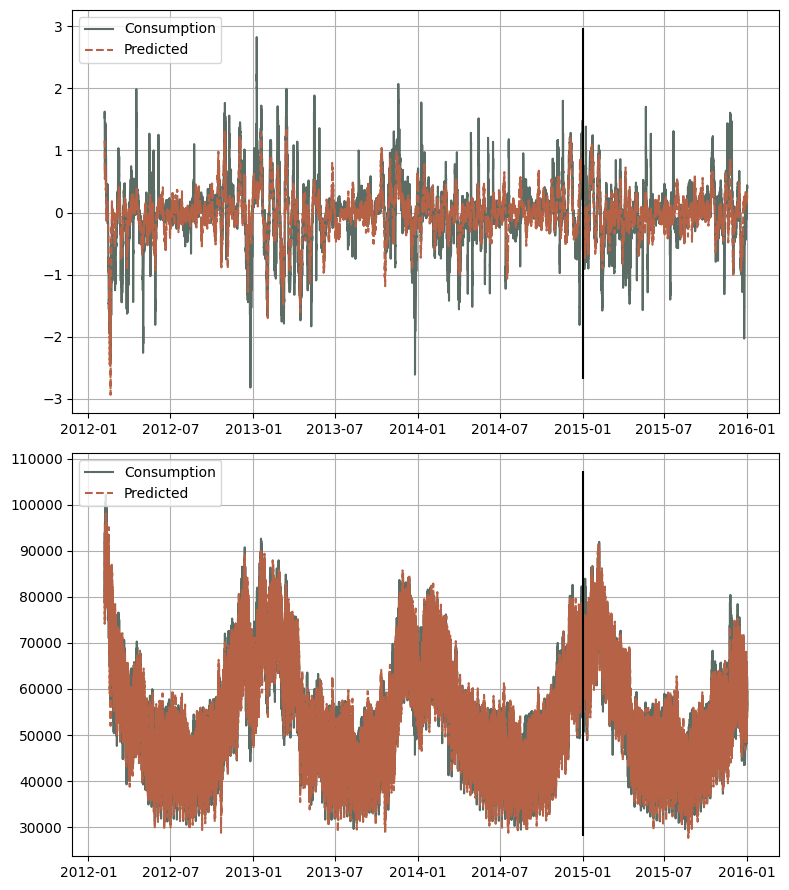

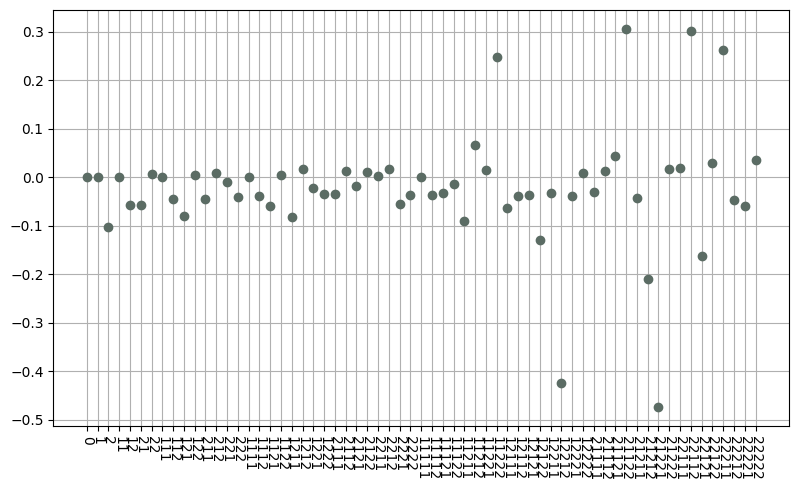

In [21]:
# 5. Fit on Train Data
# Note: y_train is already aligned with the output of sig.transform(X_train)
pipe_sliding.fit(X_train, y_train)

# 6. Predict
y_pred_sliding = pipe_sliding.predict(X_test)
y_pred_train = pipe_sliding.predict(X_train)
y_pred_test = y_pred_sliding[-len(y_test):] # Slice the test prediction to match y_test

# 7. Compute Metrics
metrics = {
    "Train": {
        "RMSE": root_mean_squared_error(y_train * NORM_CONST, y_pred_train * NORM_CONST),
        "MAE": mean_absolute_error(y_train * NORM_CONST, y_pred_train * NORM_CONST),
        "MAPE": mean_absolute_percentage_error(consumption[burn_in-delay:test_start_idx-delay] + y_train * NORM_CONST,
                                               consumption[burn_in-delay:test_start_idx-delay] + y_pred_train * NORM_CONST),
        "R2": r2_score(y_train, y_pred_train)
    },
    "Test ": {
        "RMSE": root_mean_squared_error(y_test * NORM_CONST, y_pred_test * NORM_CONST),
        "MAE": mean_absolute_error(y_test * NORM_CONST, y_pred_test * NORM_CONST),
        "MAPE": mean_absolute_percentage_error(consumption[test_start_idx - delay:-delay] + y_test * NORM_CONST,
                                               consumption[test_start_idx - delay:-delay] + y_pred_test * NORM_CONST),
        "R2": r2_score(y_test, y_pred_test)
    }
}

for split, results in metrics.items():
    print(f"{split} Metrics: " + ", ".join([f"{key} = {value:.4f}" for (key, value) in results.items()]))

fig, ax = plt.subplots(2, 1, figsize=(8, 4.5 * 2))
ax[0].plot(dates[burn_in:], y, label="Consumption")
ax[0].plot(dates[burn_in:], y_pred_sliding, "--", label="Predicted")
ax[0].vlines(x=pd.Timestamp(test_start_date), ymin=0.95 * np.min(y), ymax=1.05 * np.max(y), color="k")
ax[0].legend(loc="upper left")

ax[1].plot(dates[burn_in:], consumption[burn_in:], label="Consumption")
ax[1].plot(dates[burn_in:], consumption[burn_in-delay:-delay] + y_pred_sliding * NORM_CONST, "--", label="Predicted")
ax[1].vlines(x=pd.Timestamp(test_start_date), ymin=0.95 * np.min(consumption), ymax=1.05 * np.max(consumption), color="k")
ax[1].legend(loc="upper left")
plt.show()

vol_coef = ta.from_array(array=pipe_sliding["regressor"].coef_, dim=dim, trunc=trunc)
ta.plot_coefficients(vol_coef, trunc=trunc)

### Plots for two weeks

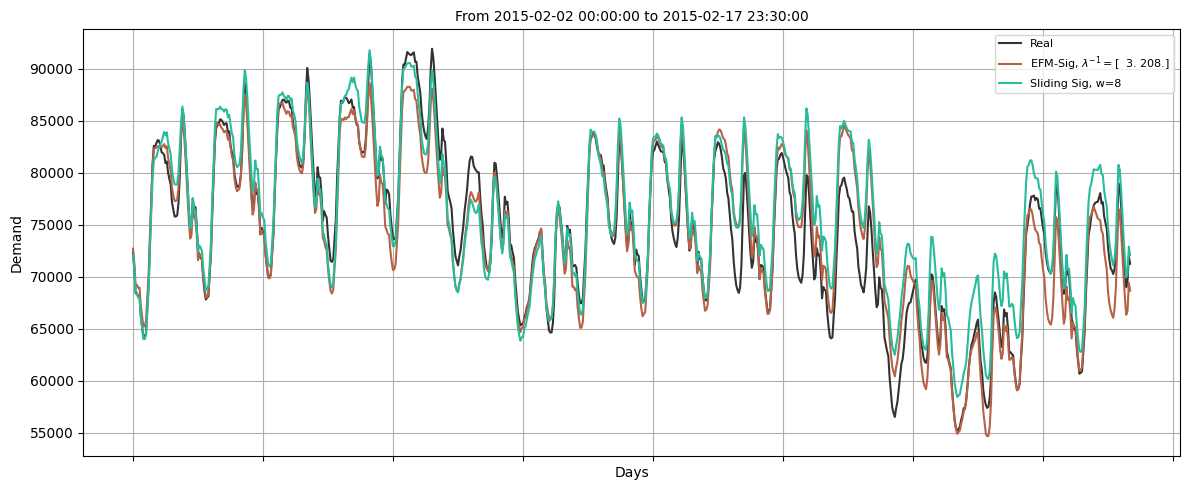

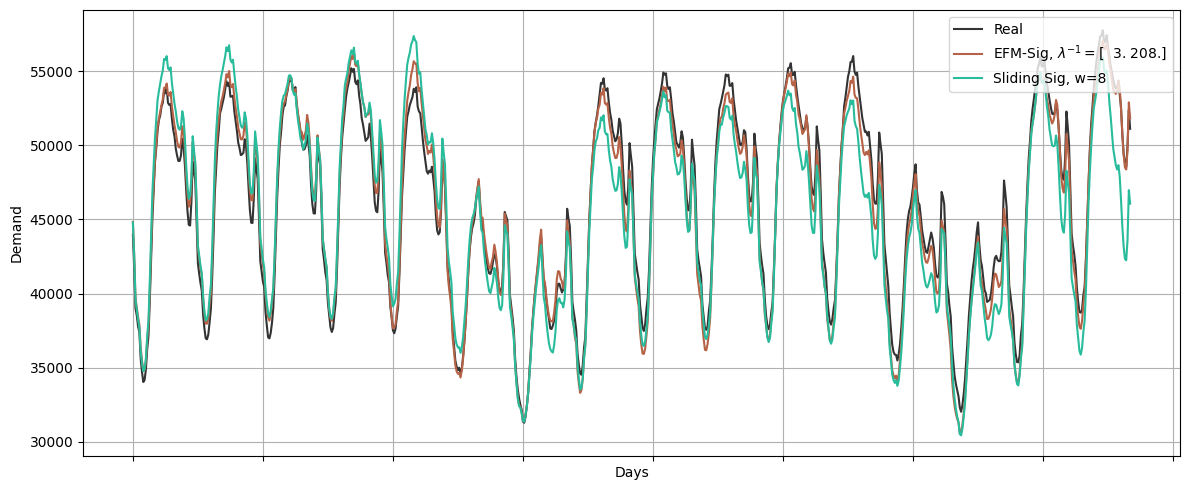

In [54]:
datetime = df["DateTime"]
y_pred_sig_efm = consumption[burn_in-delay:-delay] + y_pred_efm * NORM_CONST
y_pred_sig_sliding = consumption[burn_in-delay:-delay] + y_pred_sliding * NORM_CONST


# Align dates
dates_from_burn_in = dates[burn_in:]

# Plot
fig, axes = plt.subplots(figsize=(12, 5), sharex=True)

# First plot - winter week
start_winter = "2015-02-02 00:00:00"
end_winter  = "2015-02-17 23:30:00"

mask = (dates_from_burn_in >= start_winter) & (dates_from_burn_in <= end_winter)

axes.plot(consumption[burn_in:][mask], label="Real", color="#333333")
axes.plot(y_pred_sig_efm[mask], label=r"EFM-Sig, $\lambda^{-1}=$"+ str(np.round(1/np.array(lam) / 48)),color=color_cycle[1])
axes.plot(y_pred_sig_sliding[mask], label=f"Sliding Sig, w={int(window_size / 48)}",color=color_cycle[3])
axes.legend(loc="upper right", fontsize=8)
axes.tick_params(labelbottom=False)
axes.set_title(f"From {start_winter} to {end_winter}", fontsize=10)
axes.set_xlabel("Days",fontsize=10)
axes.set_ylabel("Demand",fontsize=10)
axes.legend(loc="upper right", fontsize=8)


fig, axes = plt.subplots(figsize=(12, 5), sharex=True)

#  Second plot - summer week
start_summer = "2015-06-15 00:00:00"
end_summer   = "2015-06-30 23:30:00"
mask_summer = (dates_from_burn_in >= start_summer) & (dates_from_burn_in <= end_summer)

axes.plot(consumption[burn_in:][mask_summer], label="Real",color="#333333")
axes.plot(y_pred_sig_efm[mask_summer], label=r"EFM-Sig, $\lambda^{-1}=$"+ str(np.round(1/np.array(lam) / 48)),color=color_cycle[1])
axes.plot(y_pred_sig_sliding[mask_summer], label=f"Sliding Sig, w={int(window_size / 48)}",color=color_cycle[3])
axes.set_ylabel("Demand")
# axes.set_title(f"From {start_summer} to {end_summer}", fontsize=10)
axes.set_xlabel("Days")
axes.legend(loc="upper right")
axes.tick_params(labelbottom=False)

fig.savefig("images/DemandPrediction.pdf", format="pdf", transparent=True, bbox_inches="tight")

plt.tight_layout()
plt.show()